In [1]:
import numpy as np
import pandas as pd 

In [2]:
import os
for dirname, _,fileanme in os.walk('/kaggle/input'):
    for filename in filename:
        os.path.join(dirname,filename)

In [3]:
!pip install tensorflow


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img
from tensorflow.keras.utils import image_dataset_from_directory

from collections import Counter
import numpy as np
import os
import shutil

from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import os

dataset_path = "blood_group_dataset"

print(os.listdir(dataset_path))


['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


In [7]:
BATCH_SIZE=32

In [8]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset = image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",      # ✅ correct
    image_size=(64, 64),
    batch_size=BATCH_SIZE,
    shuffle=True
)


Found 6000 files belonging to 8 classes.


In [10]:
class_names=dataset.class_names
class_counts=Counter()
for _, labels in dataset.unbatch():
    class_counts[int(labels.numpy())]+=1
print("Class distribution:")
for i,count in class_counts.items():
    print(f"{class_names[i]}:{count}")

Class distribution:
AB-:761
A-:1009
B+:652
O+:852
AB+:708
B-:741
A+:565
O-:712


In [21]:
import matplotlib.pyplot as plt

def plot_class_distribution(class_names, class_counts):
    classes = [class_names[i] for i in class_counts.keys()]
    counts = [class_counts[i] for i in class_counts.keys()]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, counts)
    
    plt.xlabel("Blood Group Classes")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution of Balanced Dataset")
    plt.xticks(rotation=45)
    
    # 🔹 display count on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            str(height),
            ha='center',
            va='bottom'
        )
    
    plt.tight_layout()
    plt.show()


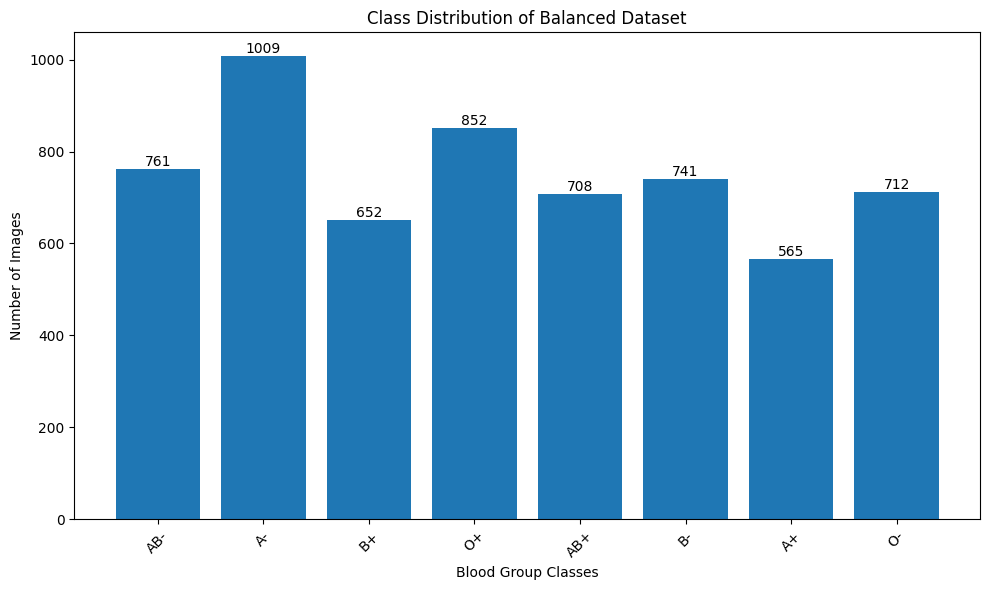

In [22]:
plot_class_distribution(class_names, class_counts)


In [23]:
max_count=max(class_counts.values())

In [24]:
# function to oversmapling a class
def oversample_class(class_id,count,max_count):
    #ensure the dataset is unbatched for filtering
    unbatched_dataset=dataset.unbatch()
    #filter the dataset for the specific class
    class_dataset=unbatched_dataset.filter(lambda img,lbl:tf.equal(lbl,class_id))
    #calculate the number of repetition needed
    repeat_factor=max_count//count+(max_count %count>0)
    # repeat the dataset to match the desired count 
    return class_dataset.repeat(repeat_factor).take(max_count)

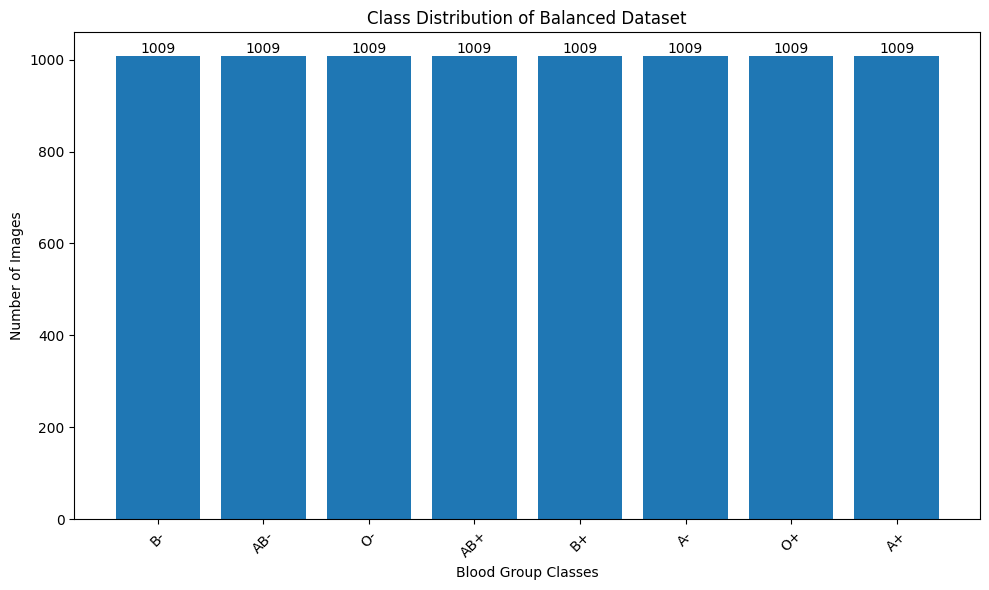

In [27]:


# balance the dataset
balanced_datasets = []

for class_id, count in class_counts.items():
    balanced_datasets.append(
        oversample_class(class_id, count, max_count)
    )

# combine all balanced class datasets
balanced_dataset = tf.data.Dataset.sample_from_datasets(balanced_datasets)

# count balanced class distribution
balanced_class_counts = Counter(
    [int(lbl.numpy()) for _, lbl in balanced_dataset]
)

# plot balanced distribution
plot_class_distribution(class_names, balanced_class_counts)
# batch and shuffle
balanced_dataset = balanced_dataset.batch(BATCH_SIZE, drop_remainder=True)


In [30]:
for sample in balanced_dataset.take(10):
    print(sample[0].shape)

(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)
(32, 64, 64, 3)


In [32]:
balanced_dataset_unbatched = balanced_dataset.unbatch()

dataset_size = sum(1 for _ in balanced_dataset_unbatched)

print(f"Total dataset size: {dataset_size}")


Total dataset size: 8064


In [36]:
# unbatch the dataset to work at the sample level
train_ratio = 0.7
val_ratio = 0.2

balanced_dataset_unbatched = balanced_dataset.unbatch()

# compute sizes based on dataset size and desired splits
train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)

# shuffle before splitting (important)
balanced_dataset_unbatched = balanced_dataset_unbatched.shuffle(1000)

# split the dataset into training, validation, and test
train_dataset = balanced_dataset_unbatched.take(train_size)
val_test_dataset = balanced_dataset_unbatched.skip(train_size)

val_dataset = val_test_dataset.take(val_size)
test_dataset = val_test_dataset.skip(val_size)

# rebatch the datasets after splitting
train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)
val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=True)
test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=True)

# check the number of batches in each dataset
train_batch_count = sum(1 for _ in train_dataset)
val_batch_count = sum(1 for _ in val_dataset)
test_batch_count = sum(1 for _ in test_dataset)

print(f"Training dataset size: {train_batch_count * BATCH_SIZE}")
print(f"Validation dataset size: {val_batch_count * BATCH_SIZE}")
print(f"Test dataset size: {test_batch_count * BATCH_SIZE}")


Training dataset size: 5632
Validation dataset size: 1600
Test dataset size: 800


In [40]:
import tensorflow as tf

def create_high_accuracy_model():

    # Data Augmentation (TRAINING ONLY)
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1),
    ])

    inputs = tf.keras.Input(shape=(64, 64, 3))
    x = data_augmentation(inputs)

    # Block 1
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.35)(x)

    # Block 4 (FINAL)
    x = tf.keras.layers.Conv2D(256, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.40)(x)

    # Better than Flatten
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Dense Head
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )(x)

    model = tf.keras.Model(inputs, outputs)

    # Label smoothing
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        label_smoothing=0.1
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss=loss_fn,
        metrics=['accuracy']
    )

    return model


In [41]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',      # ✅ correct metric
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Early stopping to stop training when validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',      # ✅ correct metric
    patience=5,
    verbose=1,
    restore_best_weights=True
)


In [42]:
# Repeat ONLY training dataset
train_dataset = train_dataset.repeat()

steps_per_epoch = train_size // BATCH_SIZE
validation_steps = val_size // BATCH_SIZE

history_high_acc = high_acc_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=75,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[reduce_lr, early_stop]
)


Epoch 1/75
176/176 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - accuracy: 0.8464 - loss: 0.4123 - val_accuracy: 0.8900 - val_loss: 0.4610 - learning_rate: 2.5000e-04
Epoch 2/75
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 189ms/step - accuracy: 0.8478 - loss: 0.3934 - val_accuracy: 0.9056 - val_loss: 0.4354 - learning_rate: 2.5000e-04
Epoch 3/75
176/176 ━━━━━━━━━━━━━━━━━━━━ 34s 196ms/step - accuracy: 0.8468 - loss: 0.4026 - val_accuracy: 0.8800 - val_loss: 0.4514 - learning_rate: 2.5000e-04
Epoch 4/75
176/176 ━━━━━━━━━━━━━━━━━━━━ 34s 193ms/step - accuracy: 0.8494 - loss: 0.3984 - val_accuracy: 0.8675 - val_loss: 0.4912 - learning_rate: 2.5000e-04
Epoch 5/75
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8660 - loss: 0.3523 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 185ms/step - accuracy: 0.8578 - loss: 0.3694 - val_accuracy: 0.8856 - val_loss: 0.4485 - learning_rate: 2.5000e-04
Epoch 6/75
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/s

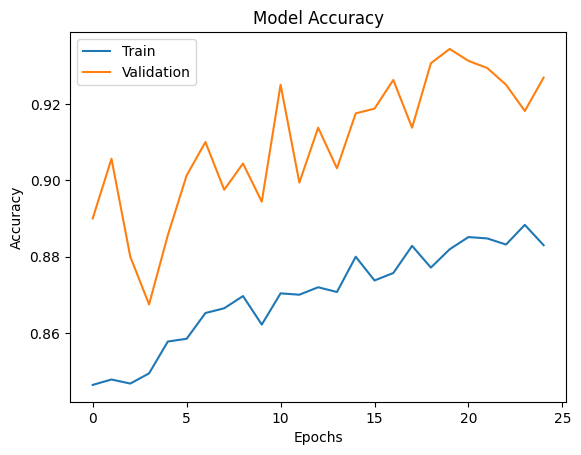

In [43]:
import matplotlib.pyplot as plt 

def plot_accuracy(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epochs')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_accuracy(history_high_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Classification Report:

              precision  

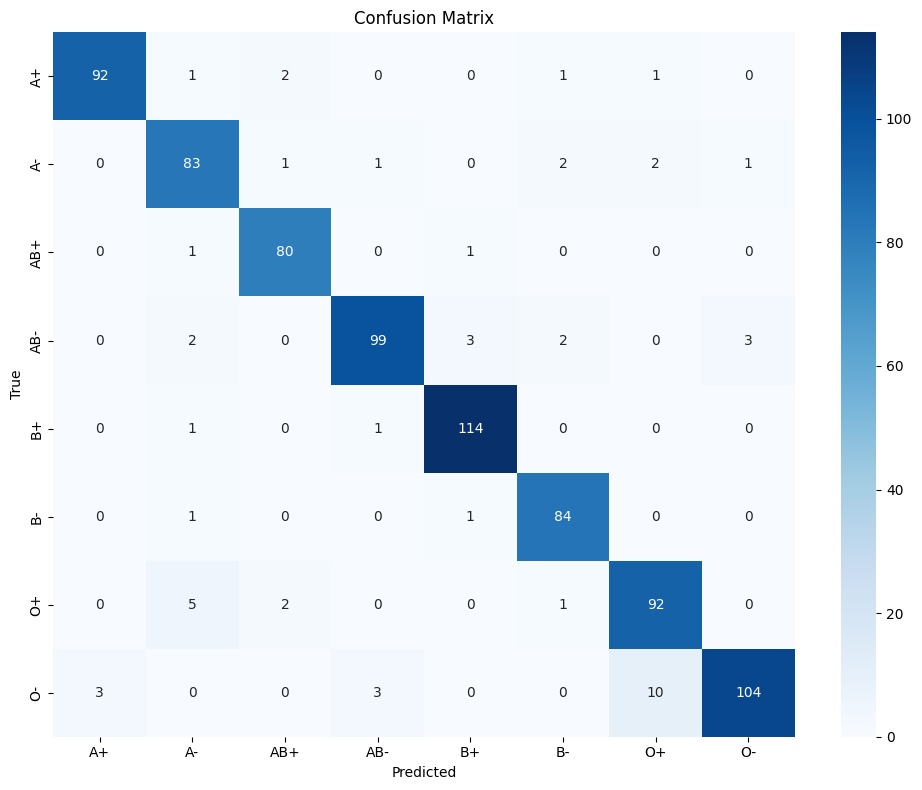

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = high_acc_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report:\n")
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [45]:
high_acc_model.save('blood_group.h5')
print("Model saved as hdf5 format")

Model saved as hdf5 format
